In [1]:
# ============================================
# CELL 1: Imports & Configuration
# ============================================

import os
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Settings
plt.style.use('seaborn-v0_8')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✅ Libraries imported!")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# ============================================
# PROJECT CONFIGURATION
# ============================================

CONFIG = {
    # Paths
    'train_csv':    '../data/processed/train_clean.csv',
    'test_csv':     '../data/processed/test_clean.csv',
    'val_csv':      '../data/processed/val_clean.csv',
    'weights_path': '../configs/class_weights.json',
    
    # Image settings
    'image_size':   224,
    'channels':     3,       # RGB (even though X-rays are grayscale)
    
    # Training settings
    'batch_size':   16,      # Small batch size for 3GB VRAM
    'num_workers':  0,
    'pin_memory':   True,
    
    # Normalization (ImageNet mean/std for transfer learning)
    'mean': [0.485, 0.456, 0.406],
    'std':  [0.229, 0.224, 0.225],
    
    # Classes
    'classes':      ['NORMAL', 'PNEUMONIA'],
    'num_classes':  2,
}

print(f"\n📋 Configuration loaded!")
print(f"  Image Size:  {CONFIG['image_size']}x{CONFIG['image_size']}")
print(f"  Batch Size:  {CONFIG['batch_size']}")
print(f"  Device:      {device}")

✅ Libraries imported!
Device: cuda
PyTorch: 2.7.1+cu118

📋 Configuration loaded!
  Image Size:  224x224
  Batch Size:  16
  Device:      cuda


In [2]:
# ============================================
# CELL 2: Load Clean Data
# ============================================

# Load CSVs saved from EDA notebook
train_df = pd.read_csv(CONFIG['train_csv'])
test_df  = pd.read_csv(CONFIG['test_csv'])
val_df   = pd.read_csv(CONFIG['val_csv'])

# Load class weights
with open(CONFIG['weights_path'], 'r') as f:
    class_weights = json.load(f)

print("✅ Data loaded successfully!")
print(f"\n📊 Dataset Summary:")
print(f"  Train: {len(train_df)} images")
print(f"  Test:  {len(test_df)} images")
print(f"  Val:   {len(val_df)} images")

print(f"\n🏷️ Train Class Distribution:")
print(train_df['label'].value_counts().to_string())

print(f"\n⚖️ Class Weights:")
for cls, weight in class_weights.items():
    print(f"  {cls}: {weight:.4f}")

# Verify filepaths exist
print(f"\n🔍 Verifying file paths...")
missing = train_df[~train_df['filepath'].apply(os.path.exists)]
print(f"  Missing files: {len(missing)}")
print(f"  All files accessible: {len(missing) == 0}")

✅ Data loaded successfully!

📊 Dataset Summary:
  Train: 5190 images
  Test:  618 images
  Val:   16 images

🏷️ Train Class Distribution:
label
PNEUMONIA    3850
NORMAL       1340

⚖️ Class Weights:
  NORMAL: 1.9366
  PNEUMONIA: 0.6740

🔍 Verifying file paths...
  Missing files: 0
  All files accessible: True


In [3]:
# ============================================
# CELL 3: Preprocessing Pipeline
# ============================================

def apply_clahe(image):
    """
    Apply CLAHE to enhance contrast in X-ray images
    Works on RGB images by converting to LAB color space
    
    Args:
        image: numpy array (H, W, C) in RGB format
    Returns:
        CLAHE enhanced image in RGB format
    """
    # Convert RGB to LAB color space
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    
    # Split into L, A, B channels
    l, a, b = cv2.split(lab)
    
    # Apply CLAHE only to L channel (brightness)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    
    # Merge channels back
    lab_enhanced = cv2.merge([l_enhanced, a, b])
    
    # Convert back to RGB
    enhanced = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)
    return enhanced


# Training augmentation pipeline
train_transforms = A.Compose([
    # Resize
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    
    # Medical imaging augmentations
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.15, 
        contrast_limit=0.15, 
        p=0.5
    ),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    A.CoarseDropout(
        num_holes_range=(1, 8),
        hole_height_range=(8, 16),
        hole_width_range=(8, 16),
        p=0.3
    ),
    
    # Normalize with ImageNet stats
    A.Normalize(
        mean=CONFIG['mean'],
        std=CONFIG['std']
    ),
    
    # Convert to PyTorch tensor
    ToTensorV2()
])

# Validation/Test pipeline (no augmentation, only resize + normalize)
val_transforms = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.Normalize(
        mean=CONFIG['mean'],
        std=CONFIG['std']
    ),
    ToTensorV2()
])

print("✅ Preprocessing pipelines created!")
print(f"\n🔄 Train Pipeline:")
print(f"  Resize → 224x224")
print(f"  HorizontalFlip (p=0.5)")
print(f"  Rotation ±15° (p=0.5)")
print(f"  Brightness/Contrast (p=0.5)")
print(f"  Gaussian Noise (p=0.3)")
print(f"  Elastic Transform (p=0.2)")
print(f"  Coarse Dropout (p=0.3)")
print(f"  CLAHE (applied before pipeline)")
print(f"  Normalize (ImageNet mean/std)")
print(f"  ToTensor")

print(f"\n✅ Val/Test Pipeline:")
print(f"  Resize → 224x224")
print(f"  Normalize (ImageNet mean/std)")
print(f"  ToTensor")

✅ Preprocessing pipelines created!

🔄 Train Pipeline:
  Resize → 224x224
  HorizontalFlip (p=0.5)
  Rotation ±15° (p=0.5)
  Brightness/Contrast (p=0.5)
  Gaussian Noise (p=0.3)
  Elastic Transform (p=0.2)
  Coarse Dropout (p=0.3)
  CLAHE (applied before pipeline)
  Normalize (ImageNet mean/std)
  ToTensor

✅ Val/Test Pipeline:
  Resize → 224x224
  Normalize (ImageNet mean/std)
  ToTensor


In [4]:
# ============================================
# CELL 4: PyTorch Dataset Class
# ============================================

class ChestXRayDataset(Dataset):
    """
    Custom PyTorch Dataset for Chest X-Ray images
    
    Args:
        dataframe:  pandas DataFrame with filepath & label columns
        transforms: albumentations transform pipeline
        apply_clahe: whether to apply CLAHE preprocessing
    """
    
    def __init__(self, dataframe, transforms=None, apply_clahe=True):
        self.df          = dataframe.reset_index(drop=True)
        self.transforms  = transforms
        self.apply_clahe = apply_clahe
        self.classes     = CONFIG['classes']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
    def __len__(self):
        """Returns total number of images in dataset"""
        return len(self.df)
    
    def __getitem__(self, idx):
        """
        Returns one image and its label at given index
        
        Args:
            idx: index of image to return
        Returns:
            image tensor, label tensor
        """
        # Get filepath and label
        row      = self.df.iloc[idx]
        filepath = row['filepath']
        label    = self.class_to_idx[row['label']]
        
        # Read image
        image = cv2.imread(filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Apply CLAHE
        if self.apply_clahe:
            image = apply_clahe(image)
        
        # Apply transforms
        if self.transforms:
            augmented = self.transforms(image=image)
            image     = augmented['image']
        
        return image, torch.tensor(label, dtype=torch.long)
    
    def get_labels(self):
        """Returns all labels — used for WeightedRandomSampler"""
        return [self.class_to_idx[label] for label in self.df['label']]


# Create dataset objects
train_dataset = ChestXRayDataset(
    dataframe=train_df,
    transforms=train_transforms,
    apply_clahe=True
)

val_dataset = ChestXRayDataset(
    dataframe=val_df,
    transforms=val_transforms,
    apply_clahe=True
)

test_dataset = ChestXRayDataset(
    dataframe=test_df,
    transforms=val_transforms,
    apply_clahe=True
)

print("✅ Datasets created!")
print(f"\n📊 Dataset Sizes:")
print(f"  Train: {len(train_dataset)} images")
print(f"  Val:   {len(val_dataset)} images")
print(f"  Test:  {len(test_dataset)} images")

# Test single item
image, label = train_dataset[0]
print(f"\n🔍 Single Item Check:")
print(f"  Image shape: {image.shape}")
print(f"  Image dtype: {image.dtype}")
print(f"  Label:       {label} ({CONFIG['classes'][label]})")
print(f"  Min pixel:   {image.min():.3f}")
print(f"  Max pixel:   {image.max():.3f}")

✅ Datasets created!

📊 Dataset Sizes:
  Train: 5190 images
  Val:   16 images
  Test:  618 images

🔍 Single Item Check:
  Image shape: torch.Size([3, 224, 224])
  Image dtype: torch.float32
  Label:       0 (NORMAL)
  Min pixel:   -2.118
  Max pixel:   2.640


In [5]:
# ============================================
# CELL 5: DataLoader Setup
# ============================================

# ---- WeightedRandomSampler for class imbalance ----
# Get all training labels
train_labels = train_dataset.get_labels()

# Assign weight to each sample based on its class
sample_weights = [
    class_weights['NORMAL'] if label == 0 else class_weights['PNEUMONIA']
    for label in train_labels
]
sample_weights = torch.tensor(sample_weights, dtype=torch.float)

# Create sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ---- Create DataLoaders ----
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    sampler=sampler,          # Use weighted sampler instead of shuffle
    num_workers=CONFIG['num_workers'],
    pin_memory=CONFIG['pin_memory']
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,            # Never shuffle val/test
    num_workers=CONFIG['num_workers'],
    pin_memory=CONFIG['pin_memory']
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=CONFIG['pin_memory']
)

print("✅ DataLoaders created!")
print(f"\n📊 DataLoader Summary:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")
print(f"  Batch size:    {CONFIG['batch_size']}")

print(f"\n⚖️ WeightedRandomSampler:")
print(f"  NORMAL sample weight:    {class_weights['NORMAL']:.4f}")
print(f"  PNEUMONIA sample weight: {class_weights['PNEUMONIA']:.4f}")
print(f"  Total samples per epoch: {len(sample_weights)}")

✅ DataLoaders created!

📊 DataLoader Summary:
  Train batches: 325
  Val batches:   1
  Test batches:  39
  Batch size:    16

⚖️ WeightedRandomSampler:
  NORMAL sample weight:    1.9366
  PNEUMONIA sample weight: 0.6740
  Total samples per epoch: 5190


In [6]:
# ============================================
# CELL 6: Verify DataLoader
# ============================================

print("🔍 Verifying DataLoader...")

# Fetch one batch
images, labels = next(iter(train_loader))

print(f"✅ Batch loaded successfully!")
print(f"\n📊 Batch Information:")
print(f"  Batch image shape: {images.shape}")
print(f"  Batch label shape: {labels.shape}")
print(f"  Image dtype:       {images.dtype}")
print(f"  Label dtype:       {labels.dtype}")
print(f"  Min pixel value:   {images.min():.3f}")
print(f"  Max pixel value:   {images.max():.3f}")

print(f"\n🏷️ Labels in this batch:")
unique, counts = torch.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {CONFIG['classes'][u]}: {c} images")

# Verify GPU transfer
images_gpu = images.to(device)
print(f"\n🚀 GPU Transfer Check:")
print(f"  Device before: {images.device}")
print(f"  Device after:  {images_gpu.device}")

# Memory check
if torch.cuda.is_available():
    memory_allocated = torch.cuda.memory_allocated() / 1024**2
    memory_reserved  = torch.cuda.memory_reserved() / 1024**2
    print(f"\n💾 GPU Memory:")
    print(f"  Allocated: {memory_allocated:.1f} MB")
    print(f"  Reserved:  {memory_reserved:.1f} MB")

print(f"\n✅ DataLoader verification complete!")

🔍 Verifying DataLoader...
✅ Batch loaded successfully!

📊 Batch Information:
  Batch image shape: torch.Size([16, 3, 224, 224])
  Batch label shape: torch.Size([16])
  Image dtype:       torch.float32
  Label dtype:       torch.int64
  Min pixel value:   -2.118
  Max pixel value:   2.640

🏷️ Labels in this batch:
  NORMAL: 8 images
  PNEUMONIA: 8 images

🚀 GPU Transfer Check:
  Device before: cpu
  Device after:  cuda:0

💾 GPU Memory:
  Allocated: 9.2 MB
  Reserved:  20.0 MB

✅ DataLoader verification complete!


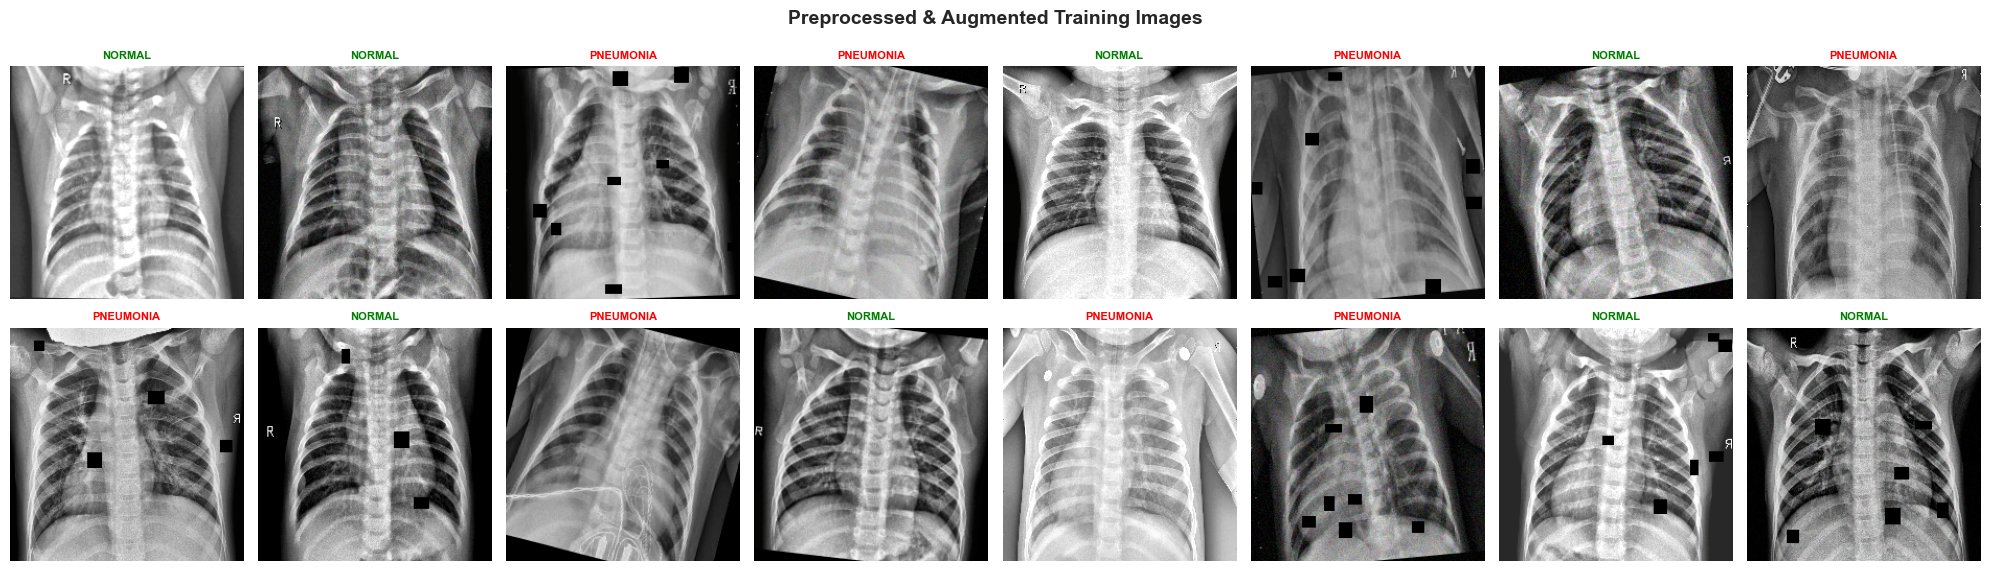

✅ Preprocessed images visualized!


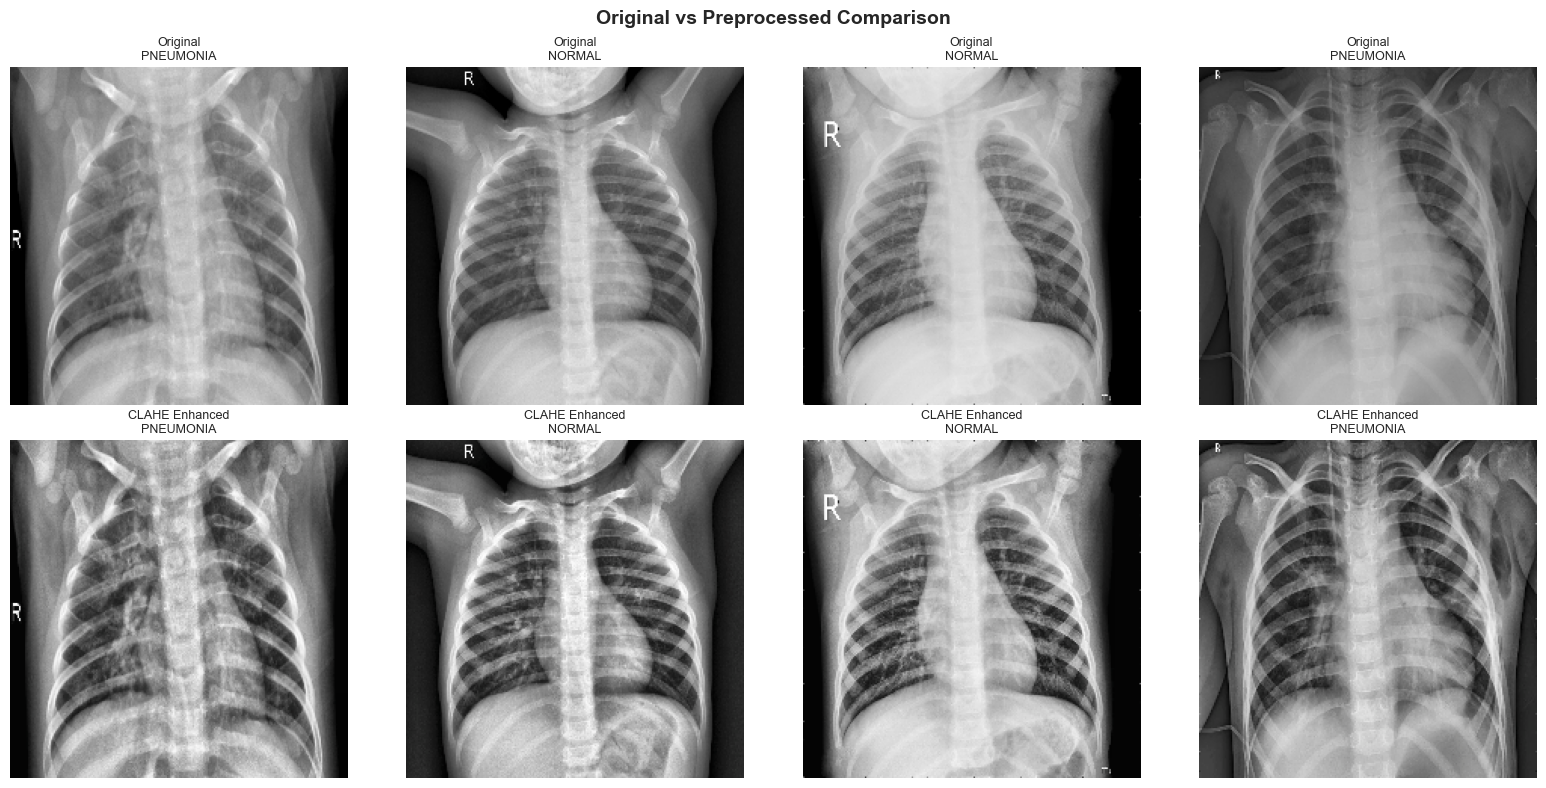

✅ Comparison plot saved!


In [7]:
# ============================================
# CELL 7: Visualize Preprocessed Images
# ============================================

def denormalize(tensor):
    """
    Reverse normalization to display images
    Args:
        tensor: normalized image tensor (C, H, W)
    Returns:
        numpy array ready for display
    """
    mean = torch.tensor(CONFIG['mean']).view(3, 1, 1)
    std  = torch.tensor(CONFIG['std']).view(3, 1, 1)
    tensor = tensor * std + mean          # Reverse normalization
    tensor = torch.clamp(tensor, 0, 1)   # Clip to valid range
    return tensor.permute(1, 2, 0).numpy()  # CHW → HWC for matplotlib


# Fetch one batch
images, labels = next(iter(train_loader))

# Plot
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Preprocessed & Augmented Training Images', 
             fontsize=14, fontweight='bold')

for i in range(16):
    row = i // 8
    col = i % 8
    
    img = denormalize(images[i])
    label_name = CONFIG['classes'][labels[i]]
    color = 'green' if label_name == 'NORMAL' else 'red'
    
    axes[row, col].imshow(img)
    axes[row, col].set_title(label_name, fontsize=8, 
                              color=color, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('../reports/figures/preprocessed_samples.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Preprocessed images visualized!")

# Compare original vs preprocessed
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Original vs Preprocessed Comparison', 
             fontsize=14, fontweight='bold')

sample_df = train_df.sample(4, random_state=42)

for idx, (_, row) in enumerate(sample_df.iterrows()):
    # Original
    orig = cv2.imread(row['filepath'])
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    orig = cv2.resize(orig, (224, 224))
    axes[0, idx].imshow(orig)
    axes[0, idx].set_title(f"Original\n{row['label']}", fontsize=9)
    axes[0, idx].axis('off')
    
    # Preprocessed (CLAHE applied)
    processed = apply_clahe(orig)
    axes[1, idx].imshow(processed)
    axes[1, idx].set_title(f"CLAHE Enhanced\n{row['label']}", fontsize=9)
    axes[1, idx].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Preprocessed', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/original_vs_preprocessed.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison plot saved!")

In [8]:
# ============================================
# CELL 8: Save Preprocessing Config
# ============================================
import yaml

# Save full config to YAML file
preprocessing_config = {
    'image_size':   CONFIG['image_size'],
    'channels':     CONFIG['channels'],
    'batch_size':   CONFIG['batch_size'],
    'num_workers':  CONFIG['num_workers'],
    'pin_memory':   CONFIG['pin_memory'],
    'mean':         CONFIG['mean'],
    'std':          CONFIG['std'],
    'classes':      CONFIG['classes'],
    'num_classes':  CONFIG['num_classes'],
    'clahe': {
        'clip_limit':    2.0,
        'tile_grid_size': [8, 8]
    },
    'augmentation': {
        'horizontal_flip':        0.5,
        'rotation_limit':         15,
        'brightness_contrast':    0.5,
        'gaussian_noise':         0.3,
        'elastic_transform':      0.2,
        'coarse_dropout':         0.3,
    }
}

with open('../configs/preprocessing_config.yaml', 'w') as f:
    yaml.dump(preprocessing_config, f, default_flow_style=False)

print("✅ Preprocessing config saved!")

# Print summary
summary = """
╔══════════════════════════════════════════════════════════╗
║         PREPROCESSING NOTEBOOK - SUMMARY                ║
╠══════════════════════════════════════════════════════════╣
║  PIPELINE                                                ║
║  • Image size:      224x224                             ║
║  • Channels:        3 (RGB)                             ║
║  • CLAHE:           Applied (clipLimit=2.0)             ║
║  • Normalization:   ImageNet mean/std                   ║
║                                                          ║
║  AUGMENTATION (Train only)                               ║
║  • Horizontal Flip:      p=0.5                          ║
║  • Rotation ±15°:        p=0.5                          ║
║  • Brightness/Contrast:  p=0.5                          ║
║  • Gaussian Noise:       p=0.3                          ║
║  • Elastic Transform:    p=0.2                          ║
║  • Coarse Dropout:       p=0.3                          ║
║                                                          ║
║  DATALOADER                                              ║
║  • Batch size:      16                                  ║
║  • Train batches:   325                                 ║
║  • Val batches:     1                                   ║
║  • Test batches:    39                                  ║
║  • Sampler:         WeightedRandomSampler               ║
║                                                          ║
║  CLASS BALANCING                                         ║
║  • NORMAL weight:    1.9366                             ║
║  • PNEUMONIA weight: 0.6740                             ║
║  • Result:          8 NORMAL, 8 PNEUMONIA per batch ✅  ║
║                                                          ║
║  SAVED ARTIFACTS                                         ║
║  • configs/preprocessing_config.yaml                    ║
║  • reports/figures/preprocessed_samples.png             ║
║  • reports/figures/original_vs_preprocessed.png         ║
╚══════════════════════════════════════════════════════════╝
"""
print(summary)
print("🎉 PREPROCESSING COMPLETE! Ready for Model Training!")

✅ Preprocessing config saved!

╔══════════════════════════════════════════════════════════╗
║         PREPROCESSING NOTEBOOK - SUMMARY                ║
╠══════════════════════════════════════════════════════════╣
║  PIPELINE                                                ║
║  • Image size:      224x224                             ║
║  • Channels:        3 (RGB)                             ║
║  • CLAHE:           Applied (clipLimit=2.0)             ║
║  • Normalization:   ImageNet mean/std                   ║
║                                                          ║
║  AUGMENTATION (Train only)                               ║
║  • Horizontal Flip:      p=0.5                          ║
║  • Rotation ±15°:        p=0.5                          ║
║  • Brightness/Contrast:  p=0.5                          ║
║  • Gaussian Noise:       p=0.3                          ║
║  • Elastic Transform:    p=0.2                          ║
║  • Coarse Dropout:       p=0.3                          ║
║   